In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import astropy.units as u
from astropy.constants import G
from numpy import pi
import spacehub_calc as sc
import matplotlib.animation as animation
import time
import itertools
from tqdm.notebook import tqdm

Initial Conditions (Change to match code):

In [ ]:
#These match the code currently (1/22)
#TODO update if changed in SpaceHub
rho = 1e-15 * u.kg / u.cm / u.cm / u.cm
cs = 50 * u.km / u.s
m0, m1 = 1*u.Msun, 1*u.Msun
a0 = 1*u.AU
e0 = 0.5  # Initial eccentricity (NEW for eccentric case)
af = 0.9 * u.AU

## General Framework for Eccentric Orbits

For an eccentric orbit with semi-major axis $a$ and eccentricity $e$:

| Quantity | Expression |
|----------|------------|
| Orbital radius | $r = \frac{a(1-e^2)}{1 + e\cos\nu}$ |
| Velocity (vis-viva) | $v^2 = Gm\left(\frac{2}{r} - \frac{1}{a}\right) = \frac{Gm}{a}\cdot\frac{1 + 2e\cos\nu + e^2}{1-e^2}$ |
| Orbital period | $T = 2\pi\sqrt{a^3/(Gm_{tot})}$ |

**Orbit-averaged quantities** use the time-weighted average:
$$\langle X \rangle = \frac{1}{T}\oint X\, dt = \frac{(1-e^2)^{3/2}}{2\pi} \int_0^{2\pi} \frac{X(\nu)}{(1+e\cos\nu)^2} d\nu$$

---

### Key Orbit Averages (derived below as needed):

| Quantity | Result |
|----------|--------|
| $\langle v^2 \rangle$ | $\frac{Gm}{a}$ (**independent of $e$!**) |
| $\langle v^3 \rangle$ | $\left(\frac{Gm}{a}\right)^{3/2} g(e)$ |
| $\langle v^{-1} \rangle$ | $\sqrt{\frac{a}{Gm}}\, h(e)$ |

where $g(e)$ and $h(e)$ are enhancement factors with $g(0) = h(0) = 1$.

---

### Critical Assumption

**We assume eccentricity remains approximately constant** ($e \approx e_0$) during the semi-major axis evolution. This is valid when:
- The eccentricity damping timescale $\tau_e \gg$ semi-major axis damping timescale $\tau_a$
- Or when we're interested in the short-term behavior

In reality, gas drag typically circularizes orbits, but often on longer timescales than $a$ evolution.

## Derivation of semi-major axis damping time $t_f(a_0, e_0, a_f)$ for Bondi-Hoyle-Littleton drag

$$F_{BH} = \frac{Am^2}{B+v^2}, \quad A=4\pi G\rho,\quad B=c_s^2$$

---

### Orbit-Averaged Energy Dissipation

The instantaneous energy loss rate is:
$$\frac{dE}{dt} = -2|F_{BH}| v = -\frac{8\pi G\rho m^2 v}{c_s^2 + v^2}$$

The orbit-averaged rate is:
$$\left\langle\frac{dE}{dt}\right\rangle = -8\pi G\rho m^2 \left\langle \frac{v}{c_s^2 + v^2} \right\rangle$$

---

### Computing the Orbit Average

Define the dimensionless parameter $\beta = \frac{c_s^2 a}{Gm}$ (inverse Mach number squared for circular orbit).

With $v^2 = \frac{Gm}{a} \cdot \frac{1 + 2e\cos\nu + e^2}{1-e^2}$, we have:

$$\frac{v}{c_s^2 + v^2} = \sqrt{\frac{a}{Gm}} \cdot \frac{\sqrt{(1 + 2e\cos\nu + e^2)/(1-e^2)}}{\beta + (1 + 2e\cos\nu + e^2)/(1-e^2)}$$

The orbit average becomes:
$$\left\langle \frac{v}{c_s^2 + v^2} \right\rangle = \sqrt{\frac{a}{Gm}} \cdot \frac{(1-e^2)^{3/2}}{2\pi} \int_0^{2\pi} \frac{\sqrt{(1 + 2e\cos\nu + e^2)/(1-e^2)}}{(1+e\cos\nu)^2 \left[\beta + \frac{1 + 2e\cos\nu + e^2}{1-e^2}\right]} d\nu$$

Define the **BHL enhancement factor**:
$$f_{BH}(e, \beta) = \frac{(1-e^2)^2}{2\pi} \int_0^{2\pi} \frac{\sqrt{1 + 2e\cos\nu + e^2}}{(1+e\cos\nu)^2 \left[\beta(1-e^2) + 1 + 2e\cos\nu + e^2\right]} d\nu$$

Then:
$$\left\langle\frac{dE}{dt}\right\rangle = -\frac{8\pi G\rho m^2}{\sqrt{Gm/a}} \cdot f_{BH}(e, \beta)$$

---

### Semi-Major Axis Evolution

Using $\frac{dE}{da} = \frac{Gm^2}{2a^2}$:

$$\frac{da}{dt} = \frac{\langle dE/dt \rangle}{dE/da} = -\frac{16\pi G\rho a^2}{\sqrt{Gm/a}} \cdot f_{BH}(e, \beta)$$

$$\frac{da}{dt} = -16\pi \rho \sqrt{\frac{G}{m}} \cdot a^{5/2} \cdot f_{BH}(e, \beta)$$

---

### Limiting Cases

**High Mach number** ($\beta \to 0$, i.e., $c_s \ll v$):
$$f_{BH}(e, 0) = h(e) = \frac{(1-e^2)^2}{2\pi} \int_0^{2\pi} \frac{d\nu}{(1+e\cos\nu)^2 \sqrt{1 + 2e\cos\nu + e^2}}$$

**Low Mach number** ($\beta \to \infty$, i.e., $c_s \gg v$):
$$f_{BH}(e, \beta) \approx \frac{1}{\beta} \cdot \frac{1}{2\pi} \int_0^{2\pi} \frac{\sqrt{1+2e\cos\nu+e^2}}{(1+e\cos\nu)^2} d\nu \cdot \frac{1}{1-e^2} = \frac{g(e)}{\beta(1-e^2)}$$

**Circular orbit** ($e = 0$): recovers $f_{BH}(0, \beta) = \frac{1}{\beta + 1}$, matching the original derivation.

---

### Final Result

$$\boxed{t_f(a_0, e_0, a_f) = \frac{1}{16\pi\rho}\sqrt{\frac{m}{G}} \int_{a_f}^{a_0} \frac{da}{a^{5/2} \cdot f_{BH}(e_0, c_s^2 a/(Gm))}}$$

**Note:** This integral generally requires numerical evaluation because $\beta = c_s^2 a/(Gm)$ varies with $a$.

---

**Assumptions:**
1. Equal masses: $m_1 = m_2 = m$
2. Eccentricity $e \approx e_0$ remains constant
3. Static, uniform gas field

In [ ]:
# Implementation of BHL damping time for eccentric orbits
from scipy import integrate

def f_BH_integrand(nu, e, beta):
    """Integrand for the BHL enhancement factor"""
    cos_nu = np.cos(nu)
    w = 1 + 2*e*cos_nu + e**2  # = (1 + e*cos(nu))^2 + e^2*sin^2(nu)
    denominator = (1 + e*cos_nu)**2 * (beta*(1-e**2) + w)
    return np.sqrt(w) / denominator

def f_BH(e, beta):
    """
    BHL enhancement factor f_BH(e, beta)
    beta = c_s^2 * a / (G*m) - inverse Mach^2 for circular orbit
    """
    if e == 0:
        return 1 / (beta + 1)
    
    prefactor = (1 - e**2)**2 / (2*np.pi)
    integral, _ = integrate.quad(f_BH_integrand, 0, 2*np.pi, args=(e, beta))
    return prefactor * integral

def sma_damping_BHL_eccentric(a0, e0, af, m, n_points=100):
    """
    BHL damping time for eccentric orbit using numerical integration.
    
    Parameters:
    -----------
    a0 : initial semi-major axis
    e0 : initial eccentricity (assumed constant)
    af : final semi-major axis
    m  : mass of each body
    n_points : number of points for numerical integration over a
    """
    # Convert to SI for numerical integration
    a0_si = a0.to(u.m).value
    af_si = af.to(u.m).value
    m_si = m.to(u.kg).value
    rho_si = rho.to(u.kg/u.m**3).value
    cs_si = cs.to(u.m/u.s).value
    G_si = G.to(u.m**3/(u.kg*u.s**2)).value
    
    # Prefactor: 1/(16*pi*rho) * sqrt(m/G)
    prefactor = np.sqrt(m_si / G_si) / (16 * np.pi * rho_si)
    
    def integrand(a):
        beta = cs_si**2 * a / (G_si * m_si)
        f = f_BH(e0, beta)
        return 1 / (a**(5/2) * f)
    
    # Numerical integration from af to a0
    result, _ = integrate.quad(integrand, af_si, a0_si)
    
    tf_seconds = prefactor * result
    return (tf_seconds * u.s).to(u.yr)

# Calculate for eccentric orbit
m = m0
print("=== BHL Drag Damping Time (Eccentric Orbit) ===\n")
print(f"Initial SMA a₀ = {a0}")
print(f"Final SMA a_f = {af}")
print(f"Eccentricity e₀ = {e0}")

# Eccentric case
tf_BHL_ecc = sma_damping_BHL_eccentric(a0, e0, af, m)
print(f"\nEccentric (e={e0}) damping time: t_f = {tf_BHL_ecc:.2f}")

# Circular case for comparison
tf_BHL_circ = sma_damping_BHL_eccentric(a0, 0, af, m)
print(f"Circular (e=0) damping time:    t_f = {tf_BHL_circ:.2f}")

print(f"\nRatio (eccentric/circular): {(tf_BHL_ecc/tf_BHL_circ).decompose():.4f}")

## Derivation of semi-major axis damping time $t_f(a_0, e_0, a_f)$ for Dynamical Friction

**From Wang et al. (2024) equation 13:**
$$\vec{F}_{dyn} = -\mathcal{I}\frac{4\pi (Gm)^2 \rho}{v^3}\vec{v}, \quad |F_{dyn}| = \mathcal{I}\frac{4\pi G^2 m^2 \rho}{v^2}$$

---

### Subsonic Regime ($\mathcal{M} < 1$): $\mathcal{I} \approx \mathcal{M}^3/3$

$$|F_{sub}| = \frac{4\pi G^2 m^2 \rho}{3} \cdot \frac{v^3}{c_s^3 v^2} = \frac{4\pi G^2 m^2 \rho v}{3 c_s^3}$$

Energy dissipation: $\frac{dE}{dt} = -2|F|v = -\frac{8\pi G^2 m^2 \rho v^2}{3 c_s^3}$

Orbit-averaged:
$$\left\langle\frac{dE}{dt}\right\rangle_{sub} = -\frac{8\pi G^2 m^2 \rho}{3 c_s^3} \langle v^2 \rangle$$

**Key result:** $\langle v^2 \rangle = Gm/a$ is **independent of eccentricity!**

*Proof:* Using $v^2 = Gm(2/r - 1/a)$ and $\langle 1/r \rangle = 1/a$:
$$\langle v^2 \rangle = Gm(2\langle 1/r \rangle - 1/a) = Gm(2/a - 1/a) = Gm/a$$

Therefore:
$$\left\langle\frac{dE}{dt}\right\rangle_{sub} = -\frac{8\pi G^3 m^3 \rho}{3 c_s^3 a}$$

This is **identical to the circular case!** The subsonic dynamical friction damping time is:

$$\boxed{t_{f,sub}(a_0, e_0, a_f) = \frac{3c_s^3}{16\pi \rho G^2 m}\ln\left(\frac{a_0}{a_f}\right) \quad \text{(independent of } e_0\text{!)}}$$

---

### Supersonic Regime ($\mathcal{M} > 1$): $\mathcal{I} \approx \Lambda$

$$|F_{sup}| = \frac{4\pi \Lambda G^2 m^2 \rho}{v^2}$$

Energy dissipation: $\frac{dE}{dt} = -2|F|v = -\frac{8\pi \Lambda G^2 m^2 \rho}{v}$

Orbit-averaged:
$$\left\langle\frac{dE}{dt}\right\rangle_{sup} = -8\pi \Lambda G^2 m^2 \rho \langle v^{-1} \rangle$$

We need $\langle v^{-1} \rangle$. With $v = \sqrt{Gm/a} \cdot \sqrt{(1+2e\cos\nu+e^2)/(1-e^2)}$:

$$\langle v^{-1} \rangle = \sqrt{\frac{a}{Gm}} \cdot h(e)$$

where the **supersonic enhancement factor** is:
$$h(e) = \frac{(1-e^2)^2}{2\pi} \int_0^{2\pi} \frac{d\nu}{(1+e\cos\nu)^2 \sqrt{1 + 2e\cos\nu + e^2}}$$

with $h(0) = 1$.

Therefore:
$$\left\langle\frac{dE}{dt}\right\rangle_{sup} = -8\pi \Lambda G^2 m^2 \rho \sqrt{\frac{a}{Gm}} \cdot h(e)$$

Following the same steps as the circular case but with the $h(e)$ factor:

$$\frac{da}{dt} = -16\pi \Lambda \rho \sqrt{\frac{G}{m}} \cdot a^{5/2} \cdot h(e_0)$$

Integrating:

$$\boxed{t_{f,sup}(a_0, e_0, a_f) = \frac{\sqrt{m}}{24\pi \Lambda \rho \sqrt{G} \cdot h(e_0)}\left(\frac{1}{a_f^{3/2}} - \frac{1}{a_0^{3/2}}\right)}$$

---

### General Case (transition from subsonic to supersonic)

If $a_0 > a_T > a_f$:

$$\boxed{t_f = \frac{3c_s^3}{16\pi \rho G^2 m}\ln\left(\frac{a_0}{a_T}\right) + \frac{\sqrt{m}}{24\pi \Lambda \rho \sqrt{G} \cdot h(e_0)}\left(\frac{1}{a_f^{3/2}} - \frac{1}{a_T^{3/2}}\right)}$$

---

**Key insight:** The subsonic regime has **no eccentricity dependence** because $\langle v^2 \rangle$ is independent of $e$. Only the supersonic regime is affected by eccentricity through $h(e)$.

---

**Assumptions:**
1. Equal masses: $m_1 = m_2 = m$
2. Eccentricity $e \approx e_0$ remains constant
3. Static, uniform gas field
4. Small-$\mathcal{M}$ approximation for subsonic
5. Large-$\mathcal{M}$ approximation for supersonic

In [ ]:
# Implementation of dynamical friction damping time for eccentric orbits

Lambda = 3  # Coulomb logarithm

def h_supersonic_integrand(nu, e):
    """Integrand for the supersonic enhancement factor h(e)"""
    cos_nu = np.cos(nu)
    w = 1 + 2*e*cos_nu + e**2
    return 1 / ((1 + e*cos_nu)**2 * np.sqrt(w))

def h_supersonic(e):
    """
    Supersonic enhancement factor h(e)
    h(0) = 1
    """
    if e == 0:
        return 1.0
    
    prefactor = (1 - e**2)**2 / (2*np.pi)
    integral, _ = integrate.quad(h_supersonic_integrand, 0, 2*np.pi, args=(e,))
    return prefactor * integral

def calc_transition_sma(m):
    """Calculate the transition semi-major axis where Mach = 1"""
    return (G * m / cs**2).decompose()

def calc_mach_circular(a, m):
    """Calculate Mach number for circular orbit at semi-major axis a"""
    v = np.sqrt(G * m / a)
    return (v / cs).decompose().value

def sma_damping_dyn_subsonic_ecc(a0, e0, af, m):
    """
    Subsonic regime: INDEPENDENT of eccentricity!
    """
    prefactor = 3 * cs**3 / (16 * pi * rho * G**2 * m)
    tf = prefactor * np.log(a0 / af)
    return tf.decompose()

def sma_damping_dyn_supersonic_ecc(a0, e0, af, m, Lambda=3):
    """
    Supersonic regime: depends on eccentricity through h(e)
    """
    h_e = h_supersonic(e0)
    prefactor = np.sqrt(m) / (24 * pi * Lambda * rho * np.sqrt(G) * h_e)
    tf = prefactor * (1/af**(3/2) - 1/a0**(3/2))
    return tf.decompose()

def sma_damping_dyn_eccentric(a0, e0, af, m, Lambda=3):
    """
    General dynamical friction damping time for eccentric orbits.
    """
    a_T = calc_transition_sma(m)
    M0 = calc_mach_circular(a0, m)
    Mf = calc_mach_circular(af, m)
    
    print(f"Transition SMA a_T = {a_T.to(u.AU):.4f}")
    print(f"Circular Mach at a₀: M₀ = {M0:.4f}")
    print(f"Circular Mach at a_f: M_f = {Mf:.4f}")
    print(f"h(e={e0}) = {h_supersonic(e0):.4f}")
    
    if M0 < 1 and Mf < 1:
        print("Regime: Fully SUBSONIC (no eccentricity dependence!)")
        return sma_damping_dyn_subsonic_ecc(a0, e0, af, m)
    
    elif M0 > 1 and Mf > 1:
        print("Regime: Fully SUPERSONIC")
        return sma_damping_dyn_supersonic_ecc(a0, e0, af, m, Lambda)
    
    elif M0 < 1 and Mf > 1:
        print("Regime: TRANSITION (subsonic → supersonic)")
        t_sub = sma_damping_dyn_subsonic_ecc(a0, e0, a_T, m)
        t_sup = sma_damping_dyn_supersonic_ecc(a_T, e0, af, m, Lambda)
        return t_sub + t_sup
    
    else:
        raise ValueError("Invalid regime")

# Calculate
print("=== Dynamical Friction Damping Time (Eccentric Orbit) ===\n")

tf_dyn_ecc = sma_damping_dyn_eccentric(a0, e0, af, m0, Lambda=Lambda)
print(f"\nEccentric (e={e0}) damping time: t_f = {tf_dyn_ecc.to(u.yr):.2f}")

# Circular for comparison
print("\n--- Circular comparison ---")
tf_dyn_circ = sma_damping_dyn_eccentric(a0, 0, af, m0, Lambda=Lambda)
print(f"\nCircular (e=0) damping time: t_f = {tf_dyn_circ.to(u.yr):.2f}")

print(f"\nRatio (eccentric/circular): {(tf_dyn_ecc/tf_dyn_circ).decompose():.4f}")

## Derivation of semi-major axis damping time $t_f(a_0, e_0, a_f)$ for Aerodynamic Drag

**From Wang et al. (2024) equation 12:**
$$|F_{aero}| = \pi R^2 \rho v^2$$

---

### Orbit-Averaged Energy Dissipation

Energy dissipation: $\frac{dE}{dt} = -2|F_{aero}| v = -2\pi R^2 \rho v^3$

Orbit-averaged:
$$\left\langle\frac{dE}{dt}\right\rangle = -2\pi R^2 \rho \langle v^3 \rangle$$

We need $\langle v^3 \rangle$. With $v = \sqrt{Gm/a} \cdot \sqrt{(1+2e\cos\nu+e^2)/(1-e^2)}$:

$$v^3 = \left(\frac{Gm}{a}\right)^{3/2} \cdot \frac{(1+2e\cos\nu+e^2)^{3/2}}{(1-e^2)^{3/2}}$$

The orbit average is:
$$\langle v^3 \rangle = \left(\frac{Gm}{a}\right)^{3/2} g(e)$$

where the **aerodynamic enhancement factor** is:
$$g(e) = \frac{1}{2\pi} \int_0^{2\pi} \frac{(1+2e\cos\nu+e^2)^{3/2}}{(1+e\cos\nu)^2} d\nu$$

with $g(0) = 1$.

---

### Semi-Major Axis Evolution

$$\left\langle\frac{dE}{dt}\right\rangle = -2\pi R^2 \rho \left(\frac{Gm}{a}\right)^{3/2} g(e_0)$$

Using $\frac{dE}{da} = \frac{Gm^2}{2a^2}$:

$$\frac{da}{dt} = \frac{-2\pi R^2 \rho (Gm)^{3/2} g(e_0) / a^{3/2}}{Gm^2/(2a^2)} = -\frac{4\pi R^2 \rho \sqrt{G}}{\sqrt{m}} a^{1/2} \cdot g(e_0)$$

---

### Integration

$$\int_{a_0}^{a_f} a^{-1/2} da = -\frac{4\pi R^2 \rho \sqrt{G} \cdot g(e_0)}{\sqrt{m}} \int_0^{t_f} dt$$

$$\boxed{t_f(a_0, e_0, a_f) = \frac{\sqrt{m}(\sqrt{a_0} - \sqrt{a_f})}{2\pi R^2 \rho \sqrt{G} \cdot g(e_0)}}$$

Or equivalently:
$$t_f(a_0, e_0, a_f) = \frac{t_{f,circ}(a_0, a_f)}{g(e_0)}$$

---

### Properties of $g(e)$

- $g(0) = 1$ (recovers circular case)
- $g(e) > 1$ for $e > 0$ (eccentric orbits damp **faster**)
- As $e \to 1$: the orbit spends more time near apocenter (slow) but pericenter (fast) dominates $\langle v^3 \rangle$

**Physical interpretation:** High-eccentricity orbits have higher peak velocities at pericenter, leading to stronger drag and faster energy dissipation.

---

**Assumptions:**
1. Equal masses: $m_1 = m_2 = m$
2. Eccentricity $e \approx e_0$ remains constant
3. Static, uniform gas field
4. Fixed effective radius $R$

In [ ]:
# Implementation of aerodynamic drag damping time for eccentric orbits

def g_aero_integrand(nu, e):
    """Integrand for the aerodynamic enhancement factor g(e)"""
    cos_nu = np.cos(nu)
    w = 1 + 2*e*cos_nu + e**2
    return w**(3/2) / (1 + e*cos_nu)**2

def g_aero(e):
    """
    Aerodynamic enhancement factor g(e)
    g(0) = 1
    """
    if e == 0:
        return 1.0
    
    integral, _ = integrate.quad(g_aero_integrand, 0, 2*np.pi, args=(e,))
    return integral / (2*np.pi)

def sma_damping_aero_eccentric(a0, e0, af, m, R):
    """
    Aerodynamic drag damping time for eccentric orbit.
    
    Parameters:
    -----------
    a0 : initial semi-major axis
    e0 : initial eccentricity (assumed constant)
    af : final semi-major axis
    m  : mass of each body
    R  : effective radius of each body
    """
    g_e = g_aero(e0)
    # Correct formula: t_f = sqrt(m) * (sqrt(a0) - sqrt(af)) / (2*pi*R^2*rho*sqrt(G)*g(e))
    prefactor = np.sqrt(m) / (2 * pi * R**2 * rho * np.sqrt(G) * g_e)
    tf = prefactor * (np.sqrt(a0) - np.sqrt(af))
    return tf.decompose()

# Example: 1 solar mass star with 1 solar radius
R_star = 1 * u.Rsun

print("=== Aerodynamic Drag Damping Time (Eccentric Orbit) ===\n")
print(f"Stellar radius R = {R_star}")
print(f"Eccentricity e₀ = {e0}")
print(f"g(e={e0}) = {g_aero(e0):.4f}")

tf_aero_ecc = sma_damping_aero_eccentric(a0, e0, af, m0, R_star)
print(f"\nEccentric (e={e0}) damping time: t_f = {tf_aero_ecc.to(u.yr):.2e}")

# Circular for comparison
tf_aero_circ = sma_damping_aero_eccentric(a0, 0, af, m0, R_star)
print(f"Circular (e=0) damping time:    t_f = {tf_aero_circ.to(u.yr):.2e}")

print(f"\nRatio (eccentric/circular): {(tf_aero_ecc/tf_aero_circ).decompose():.4f}")
print(f"(Eccentric orbit damps {'FASTER' if tf_aero_ecc < tf_aero_circ else 'SLOWER'})")

In [ ]:
# Summary: Enhancement factors as a function of eccentricity

# Compute enhancement factors for a range of eccentricities
e_values = np.linspace(0, 0.95, 50)

g_values = [g_aero(e) for e in e_values]  # Aerodynamic
h_values = [h_supersonic(e) for e in e_values]  # Dynamical friction (supersonic)

# For BHL, compute at a specific beta (e.g., beta=1, intermediate Mach regime)
beta_test = 1.0  # c_s^2 * a / (G*m) = 1 corresponds to Mach ~ 1 for circular
f_BHL_values = [f_BH(e, beta_test) for e in e_values]
f_BHL_normalized = [f / f_BH(0, beta_test) for f in f_BHL_values]  # Normalize to e=0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Enhancement factors
ax1 = axes[0]
ax1.plot(e_values, g_values, 'b-', lw=2, label=r'$g(e)$ - Aerodynamic')
ax1.plot(e_values, h_values, 'r-', lw=2, label=r'$h(e)$ - Dyn. Fric. (supersonic)')
ax1.plot(e_values, f_BHL_normalized, 'g--', lw=2, label=r'$f_{BH}(e)/f_{BH}(0)$ - BHL ($\beta=1$)')
ax1.axhline(y=1, color='k', linestyle=':', alpha=0.5)
ax1.set_xlabel('Eccentricity $e$', fontsize=12)
ax1.set_ylabel('Enhancement Factor', fontsize=12)
ax1.set_title('Enhancement Factors vs Eccentricity', fontsize=14)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

# Right: Damping time ratio (eccentric / circular)
ax2 = axes[1]
# t_f(e) / t_f(0) = 1/g(e) for aero and supersonic DF
ax2.plot(e_values, 1/np.array(g_values), 'b-', lw=2, label='Aerodynamic')
ax2.plot(e_values, 1/np.array(h_values), 'r-', lw=2, label='Dyn. Fric. (supersonic)')
ax2.plot(e_values, [1]*len(e_values), 'r--', lw=2, alpha=0.5, label='Dyn. Fric. (subsonic)')
ax2.axhline(y=1, color='k', linestyle=':', alpha=0.5)
ax2.set_xlabel('Eccentricity $e$', fontsize=12)
ax2.set_ylabel(r'$t_f(e) / t_f(e=0)$', fontsize=12)
ax2.set_title('Damping Time Ratio vs Eccentricity', fontsize=14)
ax2.legend(fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("SUMMARY: Eccentricity Effects on Semi-Major Axis Damping Time")
print("="*70)
print(f"\nFor e = {e0}:")
print(f"  g(e)  = {g_aero(e0):.4f}  →  Aerodynamic damps {g_aero(e0):.2f}x faster")
print(f"  h(e)  = {h_supersonic(e0):.4f}  →  Supersonic DF damps {h_supersonic(e0):.2f}x faster")
print(f"  Subsonic DF: NO eccentricity dependence!")
print("\nKey Results:")
print("  • Aerodynamic & Supersonic DF: Higher e → faster damping")
print("  • Subsonic DF: Damping time independent of e (remarkable!)")
print("  • BHL: Complex dependence on both e and Mach number")

In [ ]:
#Run simulation cell
if False:
    output = "test/nick_test/AnalyticalTests/FBH_damptime_circ.dat"
    compilecmd = "g++ -std=c++17 -O3 -pthread test/nick_test/KeplerSimple.cpp -o test/nick_test/KeplerSimple"
    runcmd = f"test/nick_test/KeplerSimple -rtype bh -m1 {m0.value} -m2 {m1.value} -sma {a0} -stop {(1.5*(2*np.pi)*tf_analytical.to(u.yr).value):.1f} -out {output} "
    clearcmd = "rm test/nick_test/AnalyticalTests/FBH_damptime.dat"

    if True:
        print(runcmd)
    try:
        clearstd = subprocess.run(clearcmd, shell=True, capture_output=True, text=True, timeout=15)
    except Exception as e:
        print("not cleared")
    compstd = subprocess.run(compilecmd, shell=True, capture_output=True, text=True, timeout=60)
    runstd = subprocess.run(runcmd, shell=True, capture_output=True, text=True, timeout=180)

    if runstd.returncode != 0:
        print(runstd.stderr)
    print(runstd.stdout)


test/nick_test/KeplerSimple -rtype bh -m1 1.0 -m2 1.0 -sma 1.0 AU -stop 9072.3 -out test/nick_test/AnalyticalTests/FBH_damptime_circ.dat 
Running Simulation with:
  m1  = 1 Ms
  m2  = 1 Ms
  q   = 1
  r1  = 4.24e-06 Rs (bh)
  r2  = 4.24e-06 Rs (bh)
  sma = 1 AU
  ecc = 0
  inc = 0 deg
  lan = 0 deg
  aop = 0 deg
  ta  = 0 deg
  stop= 9072.300000 yr
  atol= default
  out = test/nick_test/AnalyticalTests/FBH_damptime_circ.dat
Simulation complete in 8.23907s with no errors!



In [ ]:
orb_fbh = sc.TwoBodyOrbit("test/nick_test/AnalyticalTests/FBH_damptime_circ.dat")
tf_numerical = orb_fbh.find_crossing('a', 0.9, years=True)
#fig, axs = orb.plot_keplerian_evolution(plots=('a', 'e', 'i', 'R'), ylim=False)
#plt.show()

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within inf of constant (maximum - minimum)
Done


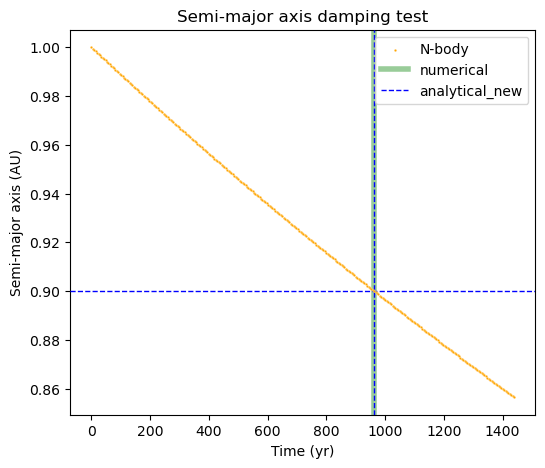

In [27]:
#Visualize the test
fig, ax =  plt.subplots(figsize=(6,5))
sns.scatterplot(x=orb_fbh.years, y=orb_fbh.semiMajorAxis, s=3, ax=ax, color="orange", label="N-body", zorder=5)

#ax.axvline(x=tf_numericalhc[0], color="blue", alpha=0.8, linestyle=":", label="numerical-hc")
ax.axvline(x=tf_numerical[0], color="green", alpha=0.4, linestyle="-", lw=4, label="numerical")
ax.axvline(x=tf_analytical.value, color="blue", alpha=1, linestyle="--", lw=1, label="analytical_new", zorder=4)
ax.axhline(y=af.to(u.AU).value, color="blue", alpha=1, linestyle="--", lw=1, zorder=4)
ax.set_ylabel("Semi-major axis (AU)")
ax.set_xlabel("Time (yr)")
ax.set_title("Semi-major axis damping test")
ax.legend()